# Abrindo

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 

from IPython.display import display


In [2]:
# Configura para mostrar todas as linhas e colunas do DataFrame
pd.set_option('display.max_rows', None)  # Exibe todas as linhas
pd.set_option('display.max_columns', None)  # Exibe todas as colunas
pd.set_option('display.width', None)  # Ajusta a largura da exibição


In [9]:
# Caminho para o arquivo Parquet
caminho_parquet = r"C:\Users\Pichau\INMET\TODAS_ESTACOES\TODAS_ESTACOES_CONCATENADO.parquet"

# Ler o arquivo Parquet
df = pd.read_parquet(caminho_parquet)

# Funções 

In [15]:
# Função para calcular a maior diferença de pressão nas duas horas anteriores
def calcular_maior_diferenca(grupo):
    grupo = grupo.copy()
    
    grupo['MAIOR_DIFERENCA_UMIDADE_2H_ATRAS'] = (
        grupo['Umidade_max'].rolling(window=2, min_periods=2).max() - 
        grupo['Umidade_min'].rolling(window=2, min_periods=2).min()
    )

    grupo['MAIOR_DIFERENCA_UMIDADE_3H_ATRAS'] = (
        grupo['Umidade_max'].rolling(window=3, min_periods=3).max() - 
        grupo['Umidade_min'].rolling(window=3, min_periods=3).min()
    )
    
    return grupo

In [17]:
# Função principal de processamento para a estação
def processar_estacao(df, estacao):
    # Filtra os dados pela estação
    estacao_df = df[df['ESTACAO'] == estacao]

    # Variáveis que quero usar
    variaveis = ['Dt_Hr', 'ESTACAO','Precip', 'Umidade_max','Umidade_min',
                 'VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE',
                 'VARIACAO SEGUNDA HORA ANTERIOR UMIDADE',
                 'VARIACAO TERCEIRA HORA ANTERIOR UMIDAD']

    estacao_df = estacao_df[variaveis]

    # Substitui os valores -9999 por NaN
    estacao_df.replace(-9999, np.nan, inplace=True)

    # Conta a quantidade de valores nulos em cada coluna
    missing_values = estacao_df.isnull().sum()
    print(missing_values)

    # Total de valores nulos no DataFrame
    total_missing_values = estacao_df.isnull().sum().sum()
    print("Total de valores nulos no DataFrame:", total_missing_values)

    estacao_df = estacao_df.reset_index(drop=True)

    # Remover linhas com valores nulos nas colunas Precip e Umidade_min
    estacao_df = estacao_df.dropna(subset=['Precip'])
    estacao_df = estacao_df.dropna(subset=['Umidade_min'])

    # Aplicar a função calcular_maior_diferenca na estação
    estacao_df = estacao_df.groupby('ESTACAO').apply(calcular_maior_diferenca).reset_index(drop=True)

    # Separa chuvas normais e extremas
    estacao_chuva = estacao_df[(estacao_df['Precip'] > 0) & (estacao_df['Precip'] < 25)]
    estacao_chuva_extrema = estacao_df[estacao_df['Precip'] >= 25]

    # Seleciona variáveis de interesse para a correlação
    variaveis_corr = ['Precip',
                      'VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE',
                      'VARIACAO SEGUNDA HORA ANTERIOR UMIDADE',
                      'VARIACAO TERCEIRA HORA ANTERIOR UMIDAD',
                      'MAIOR_DIFERENCA_UMIDADE_2H_ATRAS',
                      'MAIOR_DIFERENCA_UMIDADE_3H_ATRAS']

    # Filtra chuvas normais com variação de umidade controlada
    estacao_chuva = estacao_chuva[estacao_chuva['VARIACAO SEGUNDA HORA ANTERIOR UMIDADE'] <= 100]
    estacao_chuva = estacao_chuva[estacao_chuva['VARIACAO TERCEIRA HORA ANTERIOR UMIDAD'] <= 100]

    # Calcula a matriz de correlação para chuvas normais
    correlation_matrix_chuva = estacao_chuva[variaveis_corr].corr()

    # Gera o gráfico de correlação para chuvas normais
    plt.figure(figsize=(6, 4))
    sns.heatmap(correlation_matrix_chuva, annot=True, cmap='coolwarm', center=0)
    plt.title(f'Matriz de Correlação entre chuvas normais e variação de umidade para {estacao}')
    plt.show()

    # Calcula a matriz de correlação para chuvas extremas
    correlation_matrix_chuva_extrema = estacao_chuva_extrema[variaveis_corr].corr()

    # Gera o gráfico de correlação para chuvas extremas
    plt.figure(figsize=(6, 4))
    sns.heatmap(correlation_matrix_chuva_extrema, annot=True, cmap='coolwarm', center=0)
    plt.title(f'Matriz de Correlação entre chuvas extremas e variação de umidade para {estacao}')
    plt.show()

    print(f"\nEstatísticas Descritivas para Chuvas Normais em {estacao}:")
    display(estacao_chuva[variaveis_corr].describe())

    print(f"\nEstatísticas Descritivas para Chuvas Extremas em {estacao}:")
    display(estacao_chuva_extrema[variaveis_corr].describe())

    globals()[f'{estacao}_CHUVA'] = estacao_chuva
    globals()[f'{estacao}_CHUVA_EXTREMA'] = estacao_chuva_extrema


# Avaliando correlação de umidade : FORTE DE COPACABANA.

Dt_Hr                                          0
ESTACAO                                        0
Precip                                      5682
Umidade_max                                13142
Umidade_min                                13157
VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE     8481
VARIACAO SEGUNDA HORA ANTERIOR UMIDADE      8481
VARIACAO TERCEIRA HORA ANTERIOR UMIDAD      8481
dtype: int64
Total de valores nulos no DataFrame: 57424


C:\Users\Pichau\AppData\Local\Temp\ipykernel_15108\2533761284.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  estacao_df = estacao_df.groupby('ESTACAO').apply(calcular_maior_diferenca).reset_index(drop=True)


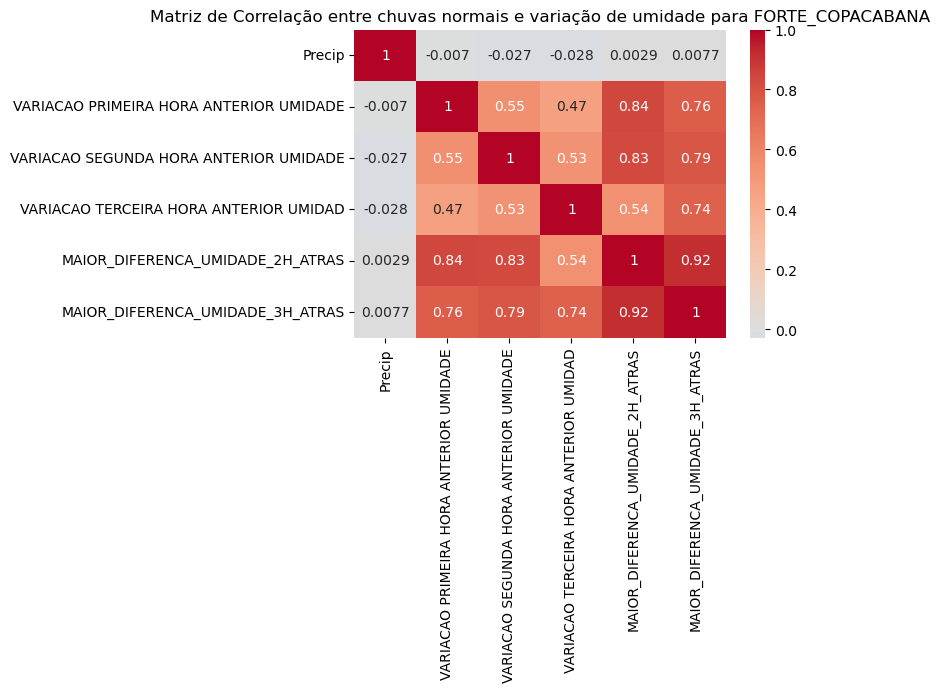

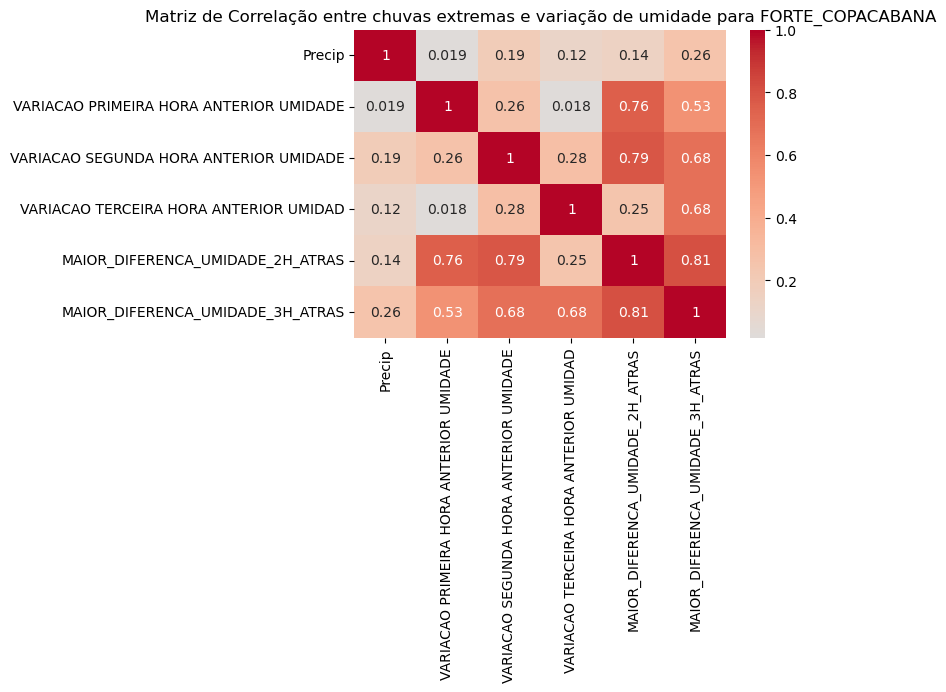


Estatísticas Descritivas para Chuvas Normais em FORTE_COPACABANA:


,Precip,VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE,VARIACAO SEGUNDA HORA ANTERIOR UMIDADE,VARIACAO TERCEIRA HORA ANTERIOR UMIDAD,MAIOR_DIFERENCA_UMIDADE_2H_ATRAS,MAIOR_DIFERENCA_UMIDADE_3H_ATRAS
count,11400.000000,11400.000000,11400.000000,11400.000000,11400.000000,11400.000000
mean,1.399632,3.433947,3.382719,3.343421,5.479035,7.066842
std,2.478456,4.074147,3.885582,3.724344,5.675596,6.640527
min,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.200000,1.000000,1.000000,1.000000,1.000000,2.000000
50%,0.600000,2.000000,2.000000,2.000000,4.000000,5.000000
75%,1.400000,5.000000,5.000000,5.000000,8.000000,10.000000
max,24.800000,73.000000,50.000000,73.000000,75.000000,75.000000



Estatísticas Descritivas para Chuvas Extremas em FORTE_COPACABANA:


,Precip,VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE,VARIACAO SEGUNDA HORA ANTERIOR UMIDADE,VARIACAO TERCEIRA HORA ANTERIOR UMIDAD,MAIOR_DIFERENCA_UMIDADE_2H_ATRAS,MAIOR_DIFERENCA_UMIDADE_3H_ATRAS
count,45.000000,45.000000,44.000000,44.000000,45.000000,45.000000
mean,37.235556,4.755556,4.522727,4.181818,8.088889,11.111111
std,11.731565,4.432091,3.769453,3.492668,5.367504,6.467479
min,25.200000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,29.000000,2.000000,2.000000,2.000000,4.000000,5.000000
50%,34.200000,4.000000,3.500000,3.500000,7.000000,12.000000
75%,39.000000,6.000000,6.250000,5.250000,13.000000,15.000000
max,71.600000,20.000000,14.000000,15.000000,24.000000,25.000000


In [31]:
processar_estacao(df, 'FORTE_COPACABANA')

# Dispersão Forte de Copacabana

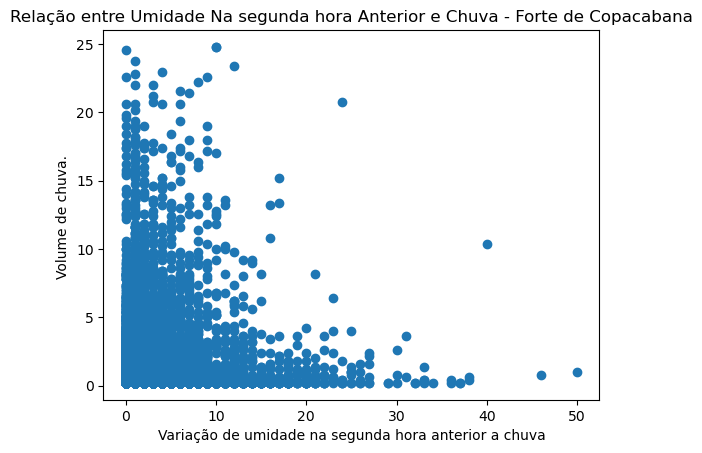

In [29]:
plt.scatter(FORTE_COPACABANA_CHUVA['VARIACAO SEGUNDA HORA ANTERIOR UMIDADE'], FORTE_COPACABANA_CHUVA['Precip'])


plt.xlabel('Variação de umidade na segunda hora anterior a chuva')

plt.ylabel('Volume de chuva. ')

plt.title('Relação entre Umidade Na segunda hora Anterior e Chuva - Forte de Copacabana')

plt.show()

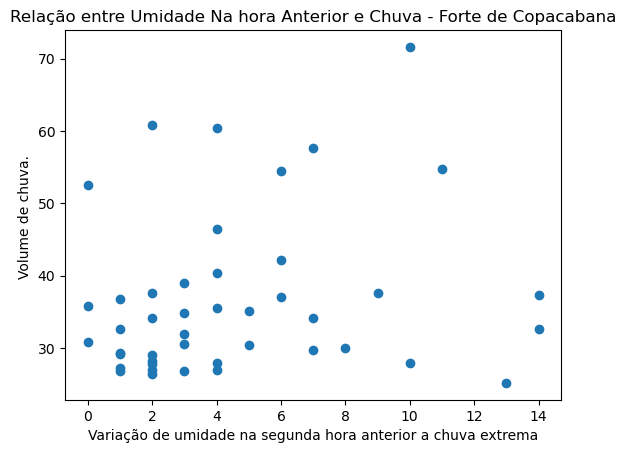

In [27]:
plt.scatter(FORTE_COPACABANA_CHUVA_EXTREMA['VARIACAO SEGUNDA HORA ANTERIOR UMIDADE'], FORTE_COPACABANA_CHUVA_EXTREMA['Precip'])


plt.xlabel('Variação de umidade na segunda hora anterior a chuva extrema')

plt.ylabel('Volume de chuva. ')

plt.title('Relação entre Umidade Na segunda hora Anterior e Chuva - Forte de Copacabana')

plt.show()

# Avaliando correlação de umidade: JACAREPAGUA


Dt_Hr                                        0
ESTACAO                                      0
Precip                                     729
Umidade_max                                750
Umidade_min                                750
VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE    705
VARIACAO SEGUNDA HORA ANTERIOR UMIDADE     706
VARIACAO TERCEIRA HORA ANTERIOR UMIDAD     707
dtype: int64
Total de valores nulos no DataFrame: 4347


C:\Users\Pichau\AppData\Local\Temp\ipykernel_15108\2533761284.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  estacao_df = estacao_df.groupby('ESTACAO').apply(calcular_maior_diferenca).reset_index(drop=True)


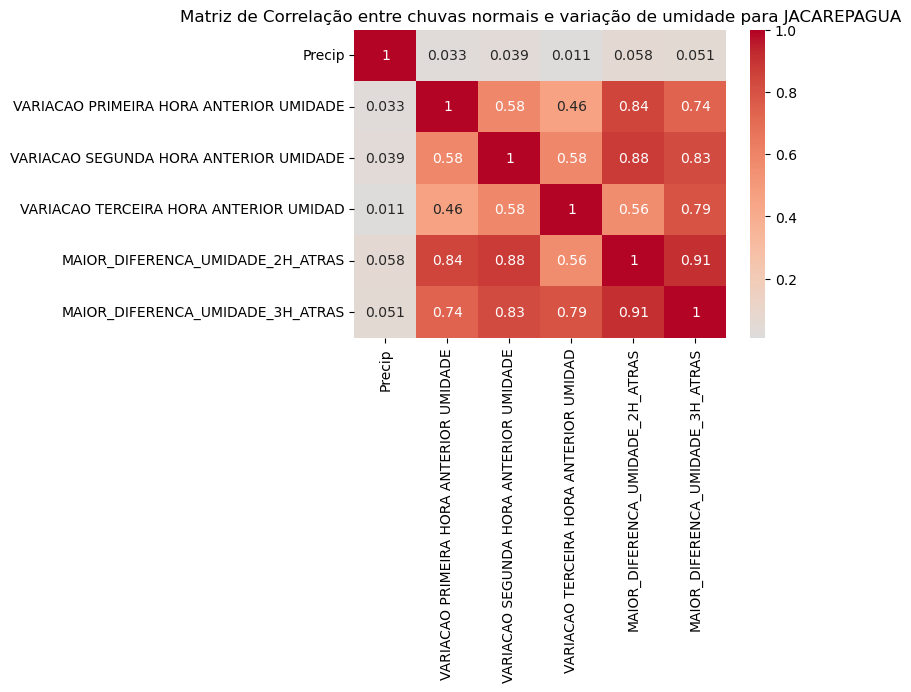

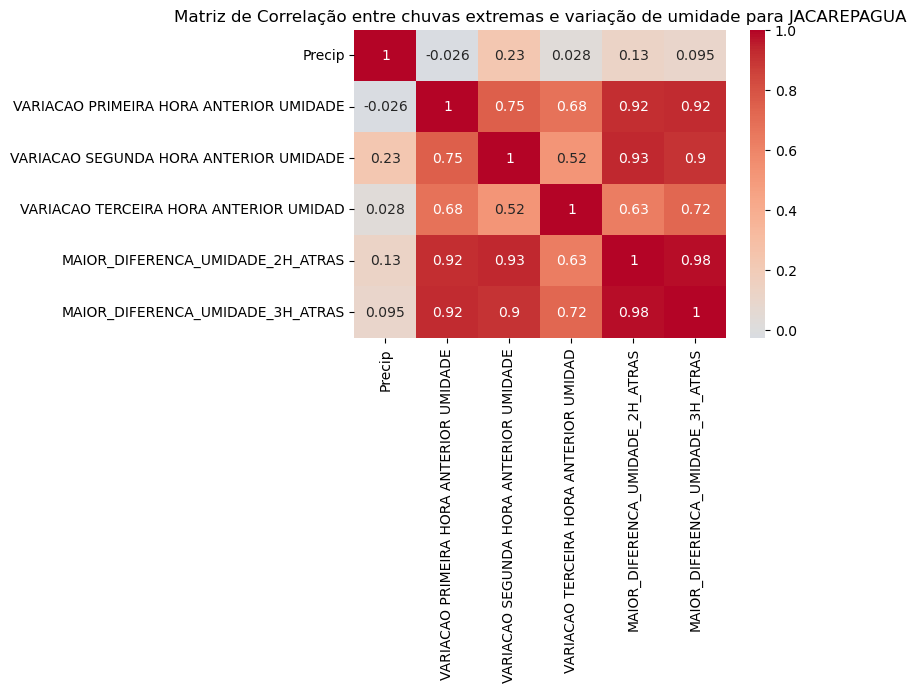


Estatísticas Descritivas para Chuvas Normais em JACAREPAGUA:


,Precip,VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE,VARIACAO SEGUNDA HORA ANTERIOR UMIDADE,VARIACAO TERCEIRA HORA ANTERIOR UMIDAD,MAIOR_DIFERENCA_UMIDADE_2H_ATRAS,MAIOR_DIFERENCA_UMIDADE_3H_ATRAS
count,5614.000000,5614.000000,5614.000000,5614.000000,5614.000000,5614.000000
mean,1.742465,3.727645,3.913609,4.113823,6.098682,8.194514
std,2.867900,4.714711,4.736625,4.784660,6.850694,8.472670
min,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.200000,1.000000,1.000000,1.000000,1.000000,2.000000
50%,0.600000,2.000000,2.000000,2.000000,4.000000,5.000000
75%,2.000000,5.000000,5.000000,6.000000,9.000000,12.000000
max,24.800000,48.000000,48.000000,48.000000,57.000000,59.000000



Estatísticas Descritivas para Chuvas Extremas em JACAREPAGUA:


,Precip,VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE,VARIACAO SEGUNDA HORA ANTERIOR UMIDADE,VARIACAO TERCEIRA HORA ANTERIOR UMIDAD,MAIOR_DIFERENCA_UMIDADE_2H_ATRAS,MAIOR_DIFERENCA_UMIDADE_3H_ATRAS
count,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000
mean,35.548387,5.580645,5.677419,4.193548,9.645161,11.580645
std,11.095461,7.079427,6.084883,3.468135,11.262174,11.943685
min,25.200000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28.400000,1.000000,1.500000,1.000000,3.000000,4.000000
50%,32.000000,3.000000,4.000000,4.000000,7.000000,8.000000
75%,38.600000,7.000000,8.000000,6.500000,13.500000,13.500000
max,80.200000,31.000000,27.000000,11.000000,55.000000,55.000000


In [34]:
processar_estacao(df, 'JACAREPAGUA')

# Dispersão JACAREPAGUA

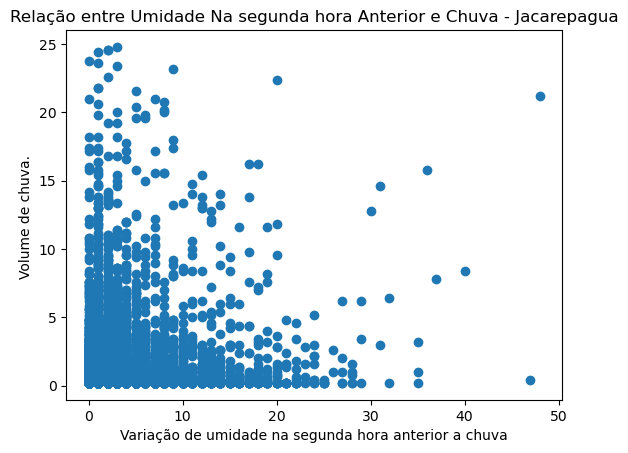

In [37]:
plt.scatter(JACAREPAGUA_CHUVA['VARIACAO SEGUNDA HORA ANTERIOR UMIDADE'], JACAREPAGUA_CHUVA['Precip'])


plt.xlabel('Variação de umidade na segunda hora anterior a chuva')

plt.ylabel('Volume de chuva. ')

plt.title('Relação entre Umidade Na segunda hora Anterior e Chuva - Jacarepagua')

plt.show()

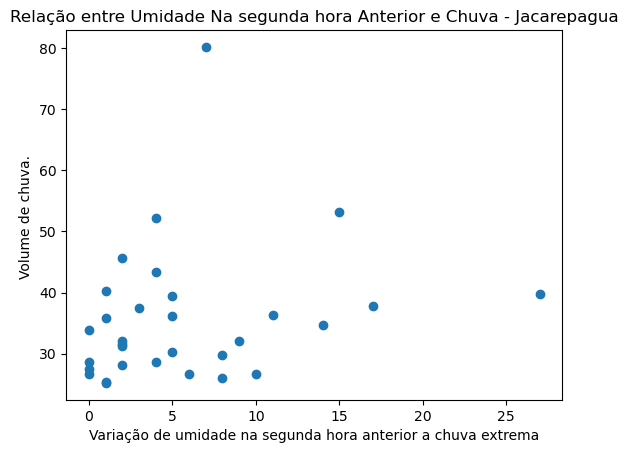

In [41]:
plt.scatter(JACAREPAGUA_CHUVA_EXTREMA['VARIACAO SEGUNDA HORA ANTERIOR UMIDADE'], JACAREPAGUA_CHUVA_EXTREMA['Precip'])


plt.xlabel('Variação de umidade na segunda hora anterior a chuva extrema')

plt.ylabel('Volume de chuva. ')

plt.title('Relação entre Umidade Na segunda hora Anterior e Chuva - Jacarepagua')

plt.show()

# Avaliando correlação de umidade: MARAMBAIA

Dt_Hr                                          0
ESTACAO                                        0
Precip                                     17701
Umidade_max                                37248
Umidade_min                                37978
VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE    17814
VARIACAO SEGUNDA HORA ANTERIOR UMIDADE     17815
VARIACAO TERCEIRA HORA ANTERIOR UMIDAD     17816
dtype: int64
Total de valores nulos no DataFrame: 146372


C:\Users\Pichau\AppData\Local\Temp\ipykernel_15108\2533761284.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  estacao_df = estacao_df.groupby('ESTACAO').apply(calcular_maior_diferenca).reset_index(drop=True)


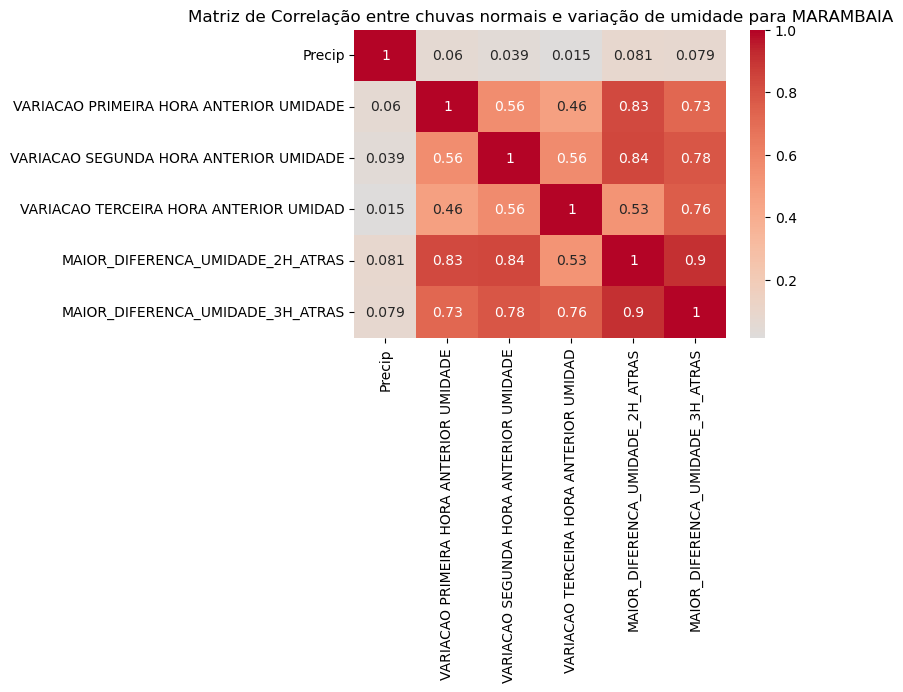

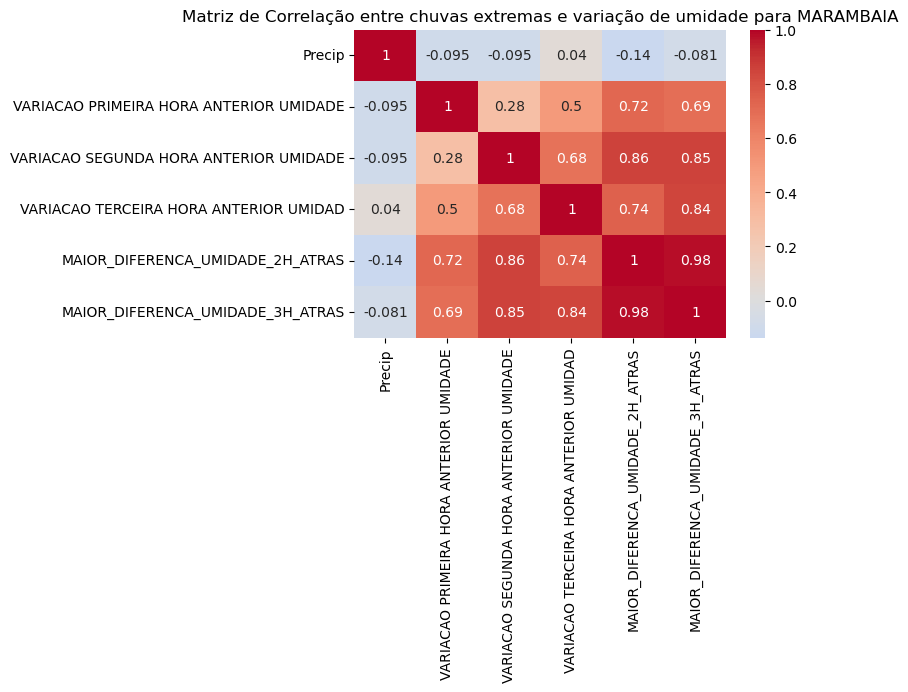


Estatísticas Descritivas para Chuvas Normais em MARAMBAIA:


,Precip,VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE,VARIACAO SEGUNDA HORA ANTERIOR UMIDADE,VARIACAO TERCEIRA HORA ANTERIOR UMIDAD,MAIOR_DIFERENCA_UMIDADE_2H_ATRAS,MAIOR_DIFERENCA_UMIDADE_3H_ATRAS
count,12002.000000,12002.000000,12002.000000,12002.000000,12002.000000,12002.000000
mean,1.490018,3.078237,3.070405,3.107149,4.988919,6.549908
std,2.513573,4.301793,4.107418,4.112251,5.965120,7.128112
min,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.200000,1.000000,1.000000,1.000000,1.000000,2.000000
50%,0.600000,2.000000,2.000000,2.000000,3.000000,4.000000
75%,1.600000,4.000000,4.000000,4.000000,7.000000,9.000000
max,24.600000,88.000000,92.000000,92.000000,100.000000,100.000000



Estatísticas Descritivas para Chuvas Extremas em MARAMBAIA:


,Precip,VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE,VARIACAO SEGUNDA HORA ANTERIOR UMIDADE,VARIACAO TERCEIRA HORA ANTERIOR UMIDAD,MAIOR_DIFERENCA_UMIDADE_2H_ATRAS,MAIOR_DIFERENCA_UMIDADE_3H_ATRAS
count,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000
mean,39.186364,5.659091,5.000000,3.772727,9.727273,11.568182
std,15.511220,7.074169,7.470874,3.722113,10.957346,11.708470
min,25.200000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,29.200000,1.750000,1.000000,1.000000,3.000000,4.000000
50%,34.600000,3.000000,3.000000,3.000000,5.000000,7.000000
75%,44.150000,6.250000,5.250000,5.000000,12.000000,15.000000
max,97.200000,33.000000,37.000000,14.000000,42.000000,49.000000


In [46]:
processar_estacao(df, 'MARAMBAIA')

# Dispersao Marambaia 

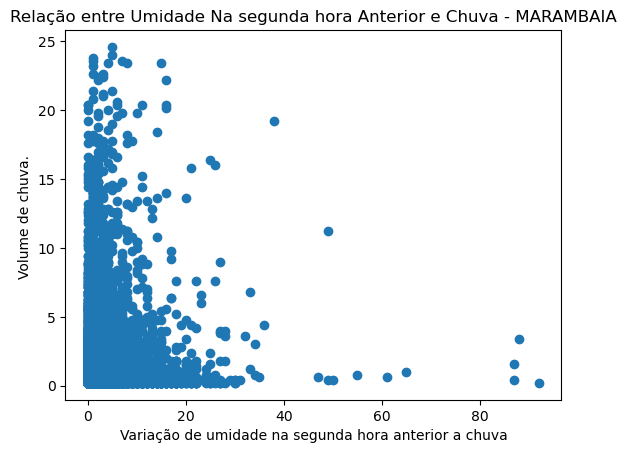

In [51]:
plt.scatter(MARAMBAIA_CHUVA['VARIACAO SEGUNDA HORA ANTERIOR UMIDADE'], MARAMBAIA_CHUVA['Precip'])


plt.xlabel('Variação de umidade na segunda hora anterior a chuva')

plt.ylabel('Volume de chuva. ')

plt.title('Relação entre Umidade Na segunda hora Anterior e Chuva - MARAMBAIA')

plt.show()

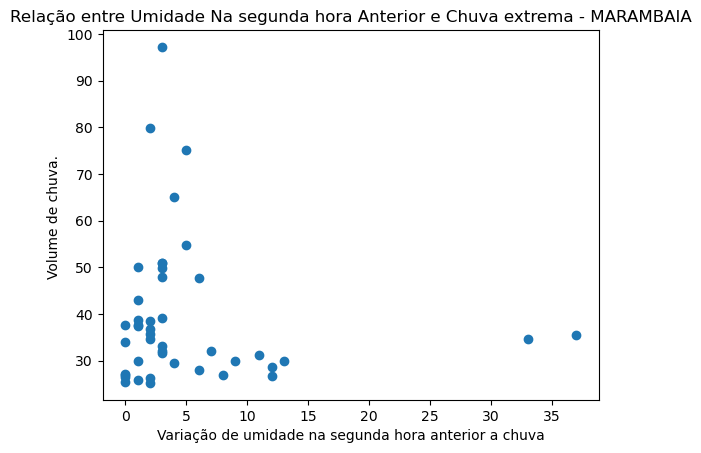

In [53]:
plt.scatter(MARAMBAIA_CHUVA_EXTREMA['VARIACAO SEGUNDA HORA ANTERIOR UMIDADE'], MARAMBAIA_CHUVA_EXTREMA['Precip'])


plt.xlabel('Variação de umidade na segunda hora anterior a chuva')

plt.ylabel('Volume de chuva. ')

plt.title('Relação entre Umidade Na segunda hora Anterior e Chuva extrema - MARAMBAIA')

plt.show()

# Avaliando correlação de umidade: VILA_MILITAR

Dt_Hr                                         0
ESTACAO                                       0
Precip                                     5709
Umidade_max                                8614
Umidade_min                                8634
VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE    3940
VARIACAO SEGUNDA HORA ANTERIOR UMIDADE     3941
VARIACAO TERCEIRA HORA ANTERIOR UMIDAD     3942
dtype: int64
Total de valores nulos no DataFrame: 34780


C:\Users\Pichau\AppData\Local\Temp\ipykernel_15108\2533761284.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  estacao_df = estacao_df.groupby('ESTACAO').apply(calcular_maior_diferenca).reset_index(drop=True)


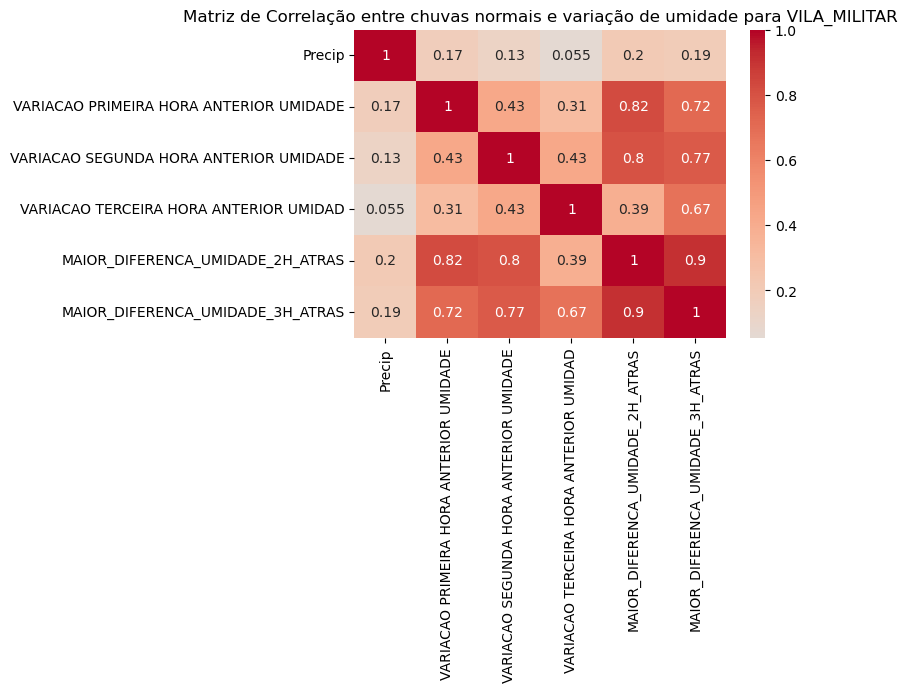

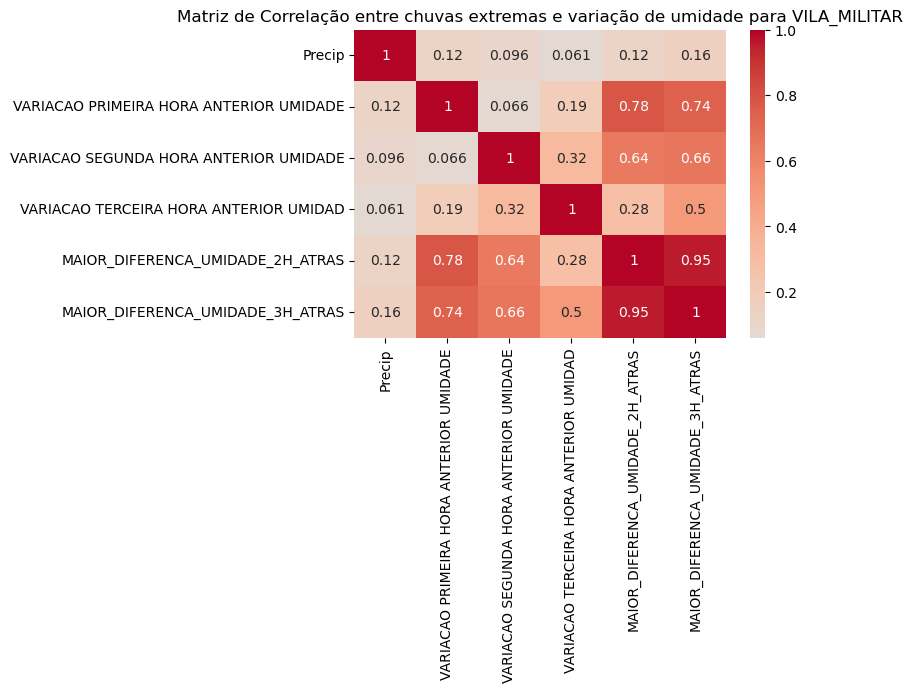


Estatísticas Descritivas para Chuvas Normais em VILA_MILITAR:


,Precip,VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE,VARIACAO SEGUNDA HORA ANTERIOR UMIDADE,VARIACAO TERCEIRA HORA ANTERIOR UMIDAD,MAIOR_DIFERENCA_UMIDADE_2H_ATRAS,MAIOR_DIFERENCA_UMIDADE_3H_ATRAS
count,11035.000000,11035.000000,11035.000000,11035.000000,11035.000000,11035.000000
mean,1.480163,5.206978,5.187041,5.077934,8.626008,11.436248
std,2.685403,5.993889,5.670184,5.232400,8.652515,10.386643
min,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.200000,1.000000,1.000000,1.000000,2.000000,3.000000
50%,0.400000,3.000000,3.000000,3.000000,6.000000,8.000000
75%,1.400000,7.000000,7.000000,7.000000,12.000000,16.000000
max,24.800000,56.000000,57.000000,56.000000,65.000000,65.000000



Estatísticas Descritivas para Chuvas Extremas em VILA_MILITAR:


,Precip,VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE,VARIACAO SEGUNDA HORA ANTERIOR UMIDADE,VARIACAO TERCEIRA HORA ANTERIOR UMIDAD,MAIOR_DIFERENCA_UMIDADE_2H_ATRAS,MAIOR_DIFERENCA_UMIDADE_3H_ATRAS
count,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000
mean,35.120000,12.928571,12.071429,7.242857,23.271429,27.142857
std,8.875134,13.649145,11.718091,5.967146,17.325462,17.820592
min,25.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,28.850000,3.250000,4.000000,3.000000,8.250000,13.500000
50%,31.800000,9.000000,9.000000,6.000000,21.000000,24.500000
75%,40.400000,17.750000,15.750000,9.000000,36.250000,40.500000
max,64.000000,57.000000,53.000000,26.000000,61.000000,61.000000


In [56]:
processar_estacao(df, 'VILA_MILITAR')

# Dispersão: Vila Militar 

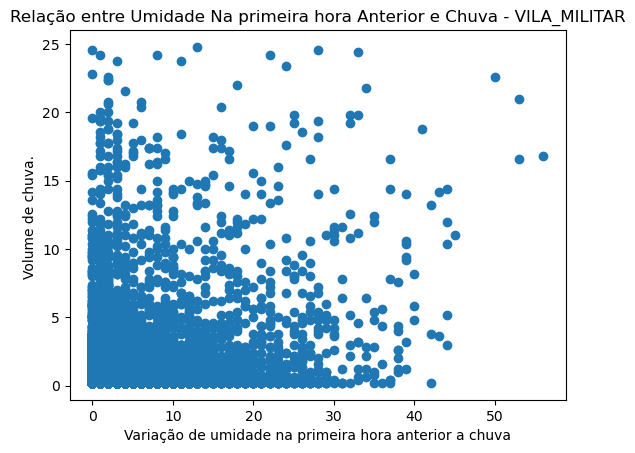

In [59]:
plt.scatter(VILA_MILITAR_CHUVA['VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE'], VILA_MILITAR_CHUVA['Precip'])


plt.xlabel('Variação de umidade na primeira hora anterior a chuva')

plt.ylabel('Volume de chuva. ')

plt.title('Relação entre Umidade Na primeira hora Anterior e Chuva - VILA_MILITAR')

plt.show()

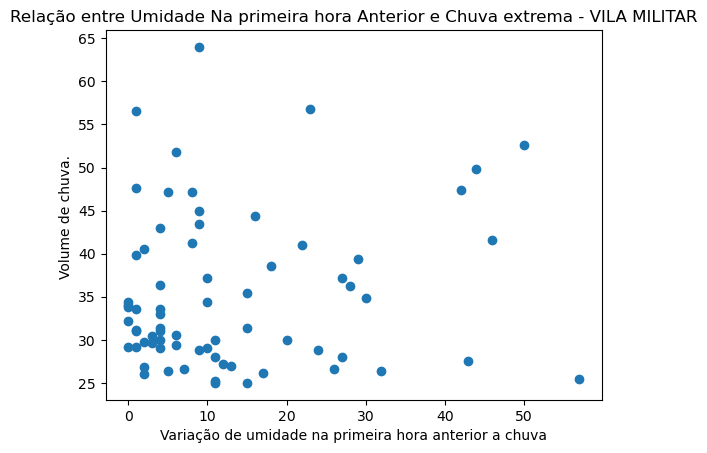

In [61]:
plt.scatter(VILA_MILITAR_CHUVA_EXTREMA['VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE'], VILA_MILITAR_CHUVA_EXTREMA['Precip'])


plt.xlabel('Variação de umidade na primeira hora anterior a chuva')

plt.ylabel('Volume de chuva. ')

plt.title('Relação entre Umidade Na primeira hora Anterior e Chuva extrema - VILA MILITAR')

plt.show()